# 1장 데이터 분석을 시작하며
##### (1) 데이터 분석이란
##### (2) 구글 코랩과 주피터 노트북
##### (3) 이 도서가 얼마나 인기가 좋을까요?

In [1]:
output ="서울특별시교육청남산도서관 장서 대출목록 (2026년 06월).csv"
import pandas as pd
df = pd.read_csv(output, encoding='utf-8')
print(df.head())

   번호        도서명             저자         출판사  발행년도           ISBN  세트 ISBN  \
0   1  플로우=Flow     긴츠 질발로디스 감독       노바미디어  2025  8809866320916      NaN   
1   2        투게더     마이클 생크스 감독  디온(The On)  2026  8800279440390      NaN   
2   3     코트 스틸링   대런 아로노프스키 감독       소니픽쳐스  2026  8809763865411      NaN   
3   4   총알 탄 사나이      아키바 샤퍼 감독       파라마운트  2025  8809931179425      NaN   
4   5    인비저블 보이  가브리엘 살바토레스 감독      유케이미디어  2026  8800240308209      NaN   

  부가기호    권 주제분류번호  도서권수  대출건수        등록일자  Unnamed: 13  
0  NaN  NaN  688.2     1     0  2026-06-30          NaN  
1  NaN  NaN  688.2     1     0  2026-06-30          NaN  
2  NaN  NaN  688.2     1     0  2026-06-30          NaN  
3  NaN  NaN  688.2     1     0  2026-06-30          NaN  
4  NaN  NaN  688.2     1     0  2026-06-30          NaN  


C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\4197475141.py:3: DtypeWarning: Columns (0: ISBN, 1: 부가기호, 2: 주제분류번호) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output, encoding='utf-8')


In [2]:
with open(output, encoding="utf-8") as f:
    print(f.readline()) #한 줄만 읽어옴
    print(f.readline())

번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,

"1","플로우=Flow ","긴츠 질발로디스 감독","노바미디어","2025","8809866320916","","","","688.2","1","0","2026-06-30",



In [3]:
#파일 인코딩 형식 확인하기
import chardet
with open(output, 'rb') as f:
    d=f.readline()
    print(chardet.detect(d))

ModuleNotFoundError: No module named 'chardet'

* CSV 파일을 데이터프레임으로 읽기: read_csv()

In [ ]:
import pandas as pd
#df = pd.read_csv(output, encoding='utf-8') #5,7,9열은 혼합된 데이터가 저장되어 있음을 경고함->파일 내용을 조금씩 나누어 읽으면서 데이터형이 다를 때 경고를 발생함
#df = pd.read_csv(output, encoding='utf-8', low_memory=False) #파일을 나누어 읽지 않고 한 번에 읽도록 함
df = pd.read_csv(output, encoding='utf-8', dtype={'ISBN': str, '부가기호': str, '주제분류번호': str}) #경고가 발생한 5,7,9열의 데이터 타입을 문자열(str)로 지정하여 읽음
df.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자,Unnamed: 13
0,1,플로우=Flow,긴츠 질발로디스 감독,노바미디어,2025,8809866320916,NaN,NaN,NaN,688.2,1,0,2026-06-30,NaN
1,2,투게더,마이클 생크스 감독,디온(The On),2026,8800279440390,NaN,NaN,NaN,688.2,1,0,2026-06-30,NaN
2,3,코트 스틸링,대런 아로노프스키 감독,소니픽쳐스,2026,8809763865411,NaN,NaN,NaN,688.2,1,0,2026-06-30,NaN
3,4,총알 탄 사나이,아키바 샤퍼 감독,파라마운트,2025,8809931179425,NaN,NaN,NaN,688.2,1,0,2026-06-30,NaN
4,5,인비저블 보이,가브리엘 살바토레스 감독,유케이미디어,2026,8800240308209,NaN,NaN,NaN,688.2,1,0,2026-06-30,NaN


In [ ]:
import openpyxl
import xlsxwriter
df.to_excel('book2.xlsx', index=False, engine='xlsxwriter') #엑셀 파일로 저장, index=False: 인덱스 열을 저장하지 않음

# 2장 데이터 수집하기
##### (1) API 사용하기
##### (2) 웹 스크래핑 사용하기

In [ ]:
# 파이썬 객체(딕셔너리, 딕셔너리 리스트)를 JSON 문자열로 변환하기
import json
d = {'name':'혼자 공부하는 데이터 분석'}
d_str = json.dumps(d, ensure_ascii=False)

print(type(d_str))

<class 'str'>


In [ ]:
#JSON 문자열을 파이썬 객체로 변환하기
d2 = json.loads(d_str)
print(d2['name'])
print(type(d2))

d3 = json.loads('{"name": "혼자 공부하는 데이터 분석", "author": "박해선", "year": 2022}')
print(d3['name'])
print(d3['author'])
print(d3['year'])

혼자 공부하는 데이터 분석
<class 'dict'>
혼자 공부하는 데이터 분석
박해선
2022


In [ ]:
#딕셔너리 내의 값이 리스트인 경우
d4_str = '{"name": "혼자 공부하는 데이터 분석", "author": ["박혜선", "홍길동"], "year": 2022}'
d4 = json.loads(d4_str)
print(d4["author"][0])
print(d4["author"][1])

#JSON 배열을 파이썬의 딕셔너리 리스트로 변환하는 경우
d5_str = """
[
    {"name": "혼자 공부하는 데이터 분석", "author": "박혜선", "year": 2022},
    {"name": "혼자 공부하는 머신러닝+딥러닝", "author": "박해선", "year": 2020}
]
"""
d5 = json.loads(d5_str)
print(d5[0]["name"])
print(d5[1]["name"])

박혜선
홍길동
혼자 공부하는 데이터 분석
혼자 공부하는 머신러닝+딥러닝


In [ ]:
#XML문자열을 파이썬 객체로 변환하기
x_str = """
    <book> 
        <name>혼자 공부하는 데이터 분석</name>
        <author>박해선</author>
        <year>2022</year>
    </book>
"""
import xml.etree.ElementTree as et
book = et.fromstring(x_str) #book은 Element 객체로 부모 엘리먼트이고 name, author, year는 자식 엘리먼트임
name = book.find("name").text #name=book.findtext("name")과 동일
author = book.find("author").text
year = book.find("year").text
print(name, author, year)

#자식 엘리먼트가 여러 개 있는 경우
x_str2 = """
<books>
    <book> 
        <name>혼자 공부하는 데이터 분석</name>
        <author>박해선</author>
        <year>2022</year>
    </book>
    <book> 
        <name>혼자 공부하는 머신러닝+딥러닝</name>
        <author>박해선</author>
        <year>2020</year>
    </book>
</books>
"""
books = et.fromstring(x_str2) #books는 Element 객체로 부모 엘리먼트이고 book은 자식 엘리먼트임
for book in books.findall("book"):
    name = book.find("name").text
    author = book.find("author").text
    year = book.find("year").text
    print(name, author, year)

혼자 공부하는 데이터 분석 박해선 2022
혼자 공부하는 데이터 분석 박해선 2022
혼자 공부하는 머신러닝+딥러닝 박해선 2020


In [ ]:
#JSON 문자열과 XML 문자열을 판다스 데이터프레임으로 변환하기
import io
import pandas as pd
d4_str = '{"name": "혼자 공부하는 데이터 분석", "author": ["박혜선", "홍길동"], "year": 2022}'
#pd.read_json(문자열): 문자열을 파일 경로로 인식함. StringIO()로 데이터 스트림임을 알려주어야 함
df4 = pd.read_json(io.StringIO(d4_str)) #StringIO는 문자열을 파일처럼 다룰 수 있도록 해주는 클래스임
print(df4)
df5 = pd.read_json(io.StringIO(d5_str))
print(df5)

print("XML 문자열을 판다스 데이터프레임으로 변환하기-1")
df6 = pd.read_xml(io.StringIO(x_str), xpath=".") #전체를 감싸는 태그가 없을 때는 xpath로 데이터의 시작점(현재 위치인 ., 이는 book임)을 지정해야 함
print(df6)
print("XML 문자열을 판다스 데이터프레임으로 변환하기-2")
df7 = pd.read_xml(io.StringIO(x_str2)) #book2 아래에 여러 개의 book이 있을 때는 xpath를 설정하지 않아도 됨
print(df7)

             name author  year
0  혼자 공부하는 데이터 분석    박혜선  2022
1  혼자 공부하는 데이터 분석    홍길동  2022
               name author  year
0    혼자 공부하는 데이터 분석    박혜선  2022
1  혼자 공부하는 머신러닝+딥러닝    박해선  2020
XML 문자열을 판다스 데이터프레임으로 변환하기-1
             name author  year
0  혼자 공부하는 데이터 분석    박해선  2022
XML 문자열을 판다스 데이터프레임으로 변환하기-2
               name author  year
0    혼자 공부하는 데이터 분석    박해선  2022
1  혼자 공부하는 머신러닝+딥러닝    박해선  2020


In [ ]:
#Yes24 사이트에서 검색 결과 페이지 가져오기
import gdown
gdown.download("https://bit.ly/3q9SZix", '20s_best_book.json', quiet=False)

Downloading...
From: https://bit.ly/3q9SZix
To: e:\working\pythonBasic\HonGong-DataAnalysis_py\20s_best_book.json
100%|██████████| 92.9k/92.9k [00:00<00:00, 1.07MB/s]


'20s_best_book.json'

In [ ]:
#JSON 파일을 읽어 판다스 데이터프레임으로 변환
import pandas as pd
books_df = pd.read_json('20s_best_book.json')
books_df.head(10)

,no,ranking,bookname,authors,publisher,publication_year,isbn13,addition_symbol,vol,class_no,class_nm,loan_count,bookImageURL
0,1,1,우리가 빛의 속도로 갈 수 없다면 :김초엽 소설,지은이: 김초엽,허블,2019,9791190090018,03810,,813.7,문학 > 한국문학 > 소설,461,https://image.aladin.co.kr/product/19359/16/co...
1,2,2,달러구트 꿈 백화점.이미예 장편소설,지은이: 이미예,팩토리나인,2020,9791165341909,03810,,813.7,문학 > 한국문학 > 소설,387,https://image.aladin.co.kr/product/24512/70/co...
2,3,3,지구에서 한아뿐 :정세랑 장편소설,지은이: 정세랑,난다,2019,9791188862290,03810,,813.7,문학 > 한국문학 > 소설,383,https://image.aladin.co.kr/product/19804/82/co...
3,4,4,"시선으로부터, :정세랑 장편소설",지은이: 정세랑,문학동네,2020,9788954672214,03810,,813.7,문학 > 한국문학 > 소설,370,https://image.aladin.co.kr/product/24131/37/co...
4,5,5,아몬드 :손원평 장편소설,지은이: 손원평,창비,2017,9788936434267,03810,,813.7,문학 > 한국문학 > 소설,365,http://image.aladin.co.kr/product/16839/4/cove...
5,6,6,피프티 피플 :정세랑 장편소설,지은이: 정세랑,창비,2016,9788936434243,03810,,813.7,문학 > 한국문학 > 소설,320,https://bookthumb-phinf.pstatic.net/cover/113/...
6,7,7,목소리를 드릴게요 :정세랑 소설집,지은이: 정세랑,아작,2020,9791165300005,03810,,813.7,문학 > 한국문학 > 소설,319,https://image.aladin.co.kr/product/22246/11/co...
7,8,8,나미야 잡화점의 기적 :히가시노 게이고 장편소설,지은이: 히가시노 게이고 ;옮긴이: 양윤옥,현대문학,2012,9788972756194,03830,,833.6,문학 > 일본문학 > 소설,312,http://image.aladin.co.kr/product/15848/6/cove...
8,9,9,선량한 차별주의자,김지혜 지음,창비,2019,9788936477196,03300,,334.0,"사회과학 > 사회학, 사회문제 > 사회문제",293,https://image.aladin.co.kr/product/19874/76/co...
9,10,9,쇼코의 미소 :최은영 소설,지은이: 최은영,문학동네,2016,9788954641630,03810,,813.7,문학 > 한국문학 > 소설,293,https://bookthumb-phinf.pstatic.net/cover/107/...


In [ ]:
#원본 데이터프레임에서 no열에서 isbn13열까지 추출하여 새로운 데이터프레임 생성
books = books_df[['no', 'ranking', 'bookname', 'authors', 'publisher', 'publication_year', 'isbn13']]
books.head()

#loc 메소드로 행과 열을 선택함: loc[[],[]]에 첫 번째 []에는 행, 두 번째 []에는 열을 지정
books2 = books_df.loc[0:3, 'bookname':'authors'] 
books2.head()

,bookname,authors
0,우리가 빛의 속도로 갈 수 없다면 :김초엽 소설,지은이: 김초엽
1,달러구트 꿈 백화점.이미예 장편소설,지은이: 이미예
2,지구에서 한아뿐 :정세랑 장편소설,지은이: 정세랑
3,"시선으로부터, :정세랑 장편소설",지은이: 정세랑


In [ ]:
#Beautiful Soup 임포트하기
from bs4 import BeautifulSoup
#객체 생성

#soup = BeautifulSoup(r.text, 'html.parser') #r은 requests.get(url)로 반환받은 Response 객체임

# 3장 데이터 정제하기
##### (1) 불필요한 데이터 삭제하기

In [ ]:
#gdown 패키지로 데이터 (남산도서관)다운로드
#import gdown
#gdown.download('https://bit.ly/3RhoNho', 'ns_202104.csv', quiet=False)

In [ ]:
#판다스 데이터프레임으로 읽고 확인을 위해 앞의 몇 줄 출력
import pandas as pd
ns_df = pd.read_csv('ns_202104.csv', low_memory=False)
#ns_df.head() #기본값으로 5줄 출력, CSV 파일의 각 행의 끝에 있는 콤마로 인해 Unnamed: 13열이 생성된 것임

In [ ]:
#loc 메소드로 열을 선택하여 새로운 데이터프레임을 만듦
ns_book = ns_df.loc[:, '번호':'등록일자']
#ns_book.head()

In [ ]:
#위에서 '번호'에서 '등록일자' 사이의 열을 제외하려면 불리언 배열을 사용해야 함
print(ns_book.columns)
selected_columns = ns_df.columns != 'Unnamed: 13'
ns_book = ns_df.loc[:, selected_columns]
#ns_book.head()

Index(['번호', '도서명', '저자', '출판사', '발행년도', 'ISBN', '세트 ISBN', '부가기호', '권',
       '주제분류번호', '도서권수', '대출건수', '등록일자'],
      dtype='str')


In [ ]:
#데이터프레임의 drop()메소드를 사용한 열 삭제
ns_book = ns_df.drop('Unnamed: 13', axis=1) #axis=1은 열을 지정한 것임
ns_book.head()
ns_book = ns_df.drop('부가기호', axis=1) 
#ns_book.head()
ns_book = ns_df.drop(['Unnamed: 13', '부가기호'], axis=1) #여러 열을 제외
#ns_book.head()

In [ ]:
#데이터프레임 자체에서 열을 제외시킴->새로운 데이터프레임을 생성하지 않음
ns_book.drop('주제분류번호', axis=1, inplace=True) #inplace=True이면 자체 업데이트함
ns_book.head()
print(ns_book.columns)

Index(['번호', '도서명', '저자', '출판사', '발행년도', 'ISBN', '세트 ISBN', '권', '도서권수',
       '대출건수', '등록일자'],
      dtype='str')


In [ ]:
#데이터프레임에서 하나이상의 NaN이 포함된 행이나 열을 삭제함
ns_book2 = ns_df.dropna(axis=1) #열을 삭제함
ns_book2.head()

,번호,ISBN,도서권수,대출건수,등록일자
0,1,9788937444319,1,0,2021-03-19
1,2,9791190123969,1,0,2021-03-19
2,3,9788968332982,1,0,2021-03-19
3,4,9788970759906,1,0,2021-03-19
4,5,9788934990833,1,0,2021-03-19


In [ ]:
#행 삭제하기: drop() 메소드 사용
print(ns_book2.columns)
ns_book3 = ns_book2.drop([0,1,3], axis=0)
ns_book3.head()

Index(['번호', 'ISBN', '도서권수', '대출건수', '등록일자'], dtype='str')


,번호,ISBN,도서권수,대출건수,등록일자
2,3,9788968332982,1,0,2021-03-19
4,5,9788934990833,1,0,2021-03-19
5,6,9791189550370,1,0,2021-03-19
6,7,9791160075793,1,0,2021-03-19
7,8,9788960906679,1,0,2021-03-19


In [ ]:
#행 삭제하기: []와 슬라이싱 사용
ns_book4 = ns_book2[2:5]
ns_book4.head()

,번호,ISBN,도서권수,대출건수,등록일자
2,3,9788968332982,1,0,2021-03-19
3,4,9788970759906,1,0,2021-03-19
4,5,9788934990833,1,0,2021-03-19


In [ ]:
#행 삭제하기: []와 불리언 배열 사용
selected_rows = ns_df['출판사']=='한빛미디어'
ns_book6 = ns_book[selected_rows]
#ns_book6.head()

In [ ]:
#중복된 행 찾기: duplicated() 메소드 사용->중복된 행은 True, 아닌 행은 False로 불리언 배열 반환
sum(ns_book.duplicated()) #sum() 계산에서 True은 1로 계산함
#중복을 판단할 열을 지정할 수 있음
print(ns_book.columns)
sum(ns_book.duplicated(subset=['도서명', '저자', 'ISBN']))
#중복된 모든 행을 True로 표시한 불리언 배열을 반환하여 모든 중복된 행을 출력함: keep=False로 지정
dup_rows = ns_book.duplicated(subset=['도서명', '저자', 'ISBN'], keep=False)
ns_book3 = ns_book[dup_rows]
#ns_book3.head()

Index(['번호', '도서명', '저자', '출판사', '발행년도', 'ISBN', '세트 ISBN', '권', '도서권수',
       '대출건수', '등록일자'],
      dtype='str')


In [ ]:
#그룹별로 모으기: 같은 도서의 대출건수를 하나로 합침, groupby() 메소드 사용
count_df = ns_book[['도서명', '저자', 'ISBN', '권', '대출건수']]
count_df.head()
group_df = count_df.groupby(by=['도서명', '저자', 'ISBN', '권'], dropna=True) #NaN 행을 삭제하지 않음
#group_df.head()
loan_count = group_df.sum()
#loan_count.head()


In [ ]:
#대출건수를 원본 데이터에 업데이트하기
dup_rows = ns_book.duplicated(subset=['도서명','저자','ISBN','권']) #중복된 행은 True로 표시
unique_rows = ~dup_rows #중복되지 않을 행을 True로 표시
ns_book7 = ns_book[unique_rows].copy() #고유한 행만 선택하여 새로 저장함
ns_book7.set_index(['도서명','저자','ISBN','권'], inplace=True) #새로운 데이터프레임을 만들지 않고 자체 데이터프레임 내에 수정
#loan_count 배열로 대출건수 데이터를 업데이트함
#print(ns_book7.index)
loan_count_clean = loan_count.reset_index().dropna(subset=['도서명','저자','ISBN','권'])
loan_count_clean.set_index(['도서명','저자','ISBN','권'], inplace=True)
ns_book7.update(loan_count_clean) #인덱스에 결측치(NaN)이 있으면 오류가 발생함
ns_book7.head()
ns_book7 = ns_book7.reset_index()
print(sum(ns_book['대출건수']>100))
print(sum(ns_book7['대출건수']>100))

2311
2223


In [ ]:
#쉬어가기: 수동으로 데이터프레임 만들기, 행 인덱스, 열 이름
import pandas as pd
import numpy as np
df1 = pd.DataFrame({
    'A': [1, 2, np.nan, 4], #A열의 데이터
    'B': [10, np.nan, 30, 40] #B열의 데이터
}, index=['a', 'b', 'c', 'd']) #행 인덱스(4개의 행)
df1.head()

,A,B
a,1.0,10.0
b,2.0,NaN
c,NaN,30.0
d,4.0,40.0


In [ ]:
#불필요한 행과 열을 제거하는 일괄처리 함수 만들기
def data_cleaning(filename):
    ns_df = pd.read_csv(filename, low_memory=False)
    ns_book = ns_df.dropna(axis=1, how='all') #열이 모두 NaN인 열을 삭제함
    count_df = ns_book[['도서명', '저자', 'ISBN', '권', '대출건수']]
    loan_count = count_df.groupby(by=['도서명', '저자', 'ISBN', '권'], dropna=True).sum()
    dup_rows = ns_book.duplicated(subset=['도서명', '저자', 'ISBN', '권'])
    ns_book3 = ns_book[~dup_rows].copy()
    loan_count_clean = loan_count.reset_index().dropna(subset=['도서명','저자','ISBN','권'])
    loan_count_clean.set_index(['도서명','저자','ISBN','권'], inplace=True)
    ns_book3.update(loan_count_clean)
    ns_book4 = ns_book3.reset_index()
    ns_book4 = ns_book4[ns_book.columns]
    return ns_book4

In [ ]:
new_ns_book4 = data_cleaning('ns_202104.csv')
ns_book4.equals(new_ns_book4) #데이터프레임끼리 비교할 때 equals() 사용

False

##### (2) 잘못된 데이터 수정하기

In [ ]:
import gdown
gdown.download('http://bit.ly/3GisL6J', 'ns_book4.csv', quiet=False )

Downloading...
From: http://bit.ly/3GisL6J
To: e:\working\pythonBasic\HonGong-DataAnalysis_py\ns_book4.csv
100%|██████████| 55.5M/55.5M [00:01<00:00, 38.3MB/s]


'ns_book4.csv'

In [ ]:
#데이터프레임으로 저장
import pandas as pd
ns_book4 = pd.read_csv('ns_book4.csv', low_memory=False)
ns_book4.head()
ns_book4.info(memory_usage='deep') #데이터프레임의 메모리 사용량 확인

<class 'pandas.DataFrame'>
RangeIndex: 384591 entries, 0 to 384590
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   번호       384591 non-null  int64  
 1   도서명      384188 non-null  str    
 2   저자       384393 non-null  str    
 3   출판사      379950 non-null  str    
 4   발행년도     384577 non-null  str    
 5   ISBN     384591 non-null  str    
 6   세트 ISBN  56576 non-null   str    
 7   부가기호     310386 non-null  str    
 8   권        63378 non-null   str    
 9   주제분류번호   364727 non-null  str    
 10  도서권수     384591 non-null  int64  
 11  대출건수     384591 non-null  float64
 12  등록일자     384591 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 266.2 MB


In [ ]:
#누락된 값 처리하기
ns_book4.isna().sum() #각 열의 NaN 개수 확인

번호              0
도서명           403
저자            198
출판사          4641
발행년도           14
ISBN            0
세트 ISBN    328015
부가기호        74205
권          321213
주제분류번호      19864
도서권수            0
대출건수            0
등록일자            0
dtype: int64

In [ ]:
#누락된 값을 빈 문자열로 대체하기
set_isbn_na_rows = ns_book4['세트 ISBN'].isna() #누락된 값을 불리언 배열로 반환
ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = '' #누락된 값을 빈 문자열로 대체
ns_book4.isna().sum() #각 열의 NaN 개수 확인

번호              0
도서명           403
저자            198
출판사          4641
발행년도           14
ISBN            0
세트 ISBN         0
부가기호        74205
권          321213
주제분류번호      19864
도서권수            0
대출건수            0
등록일자            0
dtype: int64

In [ ]:
invalid_number = ns_book4['발행년도'].str.contains('\D', na=True) #발행년도 열에 숫자가 아닌 문자가 있는지 확인, na=True이면 NaN은 True로 간주함
print(invalid_number.sum())
ns_book4[invalid_number].head() 
#연도의 앞과 뒤에 있는 문자를 제거함
ns_book5 = ns_book4.replace({'발행년도':{r'.*(\d{4}).*':r'\1'}}, regex=True)
ns_book5[invalid_number].head()

#발행년도에서 문자나 NaN이 있는 행의 개수를 출력함
unknown_year_rows = ns_book5['발행년도'].str.contains('\D', na=True)
print(unknown_year_rows.sum())

1777
67


In [ ]:
#문자나 NaN이 있는 발행년도나 4000이 넘는 발행년도를 -1로 지정함
ns_book5.loc[unknown_year_rows, '발행년도'] = '-1'
ns_book5 = ns_book5.astype({'발행년도': 'int32'}) 
#4000이 넘는 발생년도의 개수 출력
ns_book5['발행년도'].gt(4000).sum() #이는 (ns_book5['발행년도']>4000).sum()와 동일함
#4000이 넘는 발행년도를 가진 행을 추출함
dangun_yy_rows = ns_book5['발행년도'].gt(4000)
#이 년도를 2333년을 빼서 서기로 바꿈
ns_book5.loc[dangun_yy_rows, '발행년도'] = ns_book5.loc[dangun_yy_rows, '발행년도'] - 2333
#다시 4000이 넘는 발생년도의 개수 출력
print(ns_book5['발행년도'].gt(4000).sum())
dangun_yy_rows2 = ns_book5['발행년도'].gt(4000)
#두 번째로 4000이 넘는 발행년도를 가진 행을 -1로 지정함
ns_book5.loc[dangun_yy_rows2, '발행년도'] = -1

13


In [ ]:
#발행년도가 0보다 크고 1900보다 작은 경우를 찾아 -1로 지정함
old_year_rows = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)
ns_book5.loc[old_year_rows, '발행년도'] = -1
#발행년도가 -1인 행의 개수 
ns_book5['발행년도'].eq(-1).sum() 

np.int64(86)

In [ ]:
#도서명, 저자, 출판사, 발행년도가 -1인 행의 수를 출력함
na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())
#누락된 정보를 채우기 위해 requests 패키지와 BeautifulSoup 패키지를 사용하여 Yes24 사이트에서 도서 정보를 가져옴
import requests
from bs4 import BeautifulSoup
#yes24에서 isbn을 기준으로 도서명을 가져오는 함수
def get_book_title(isbn):
    url = f'https://www.yes24.com/Product/Search?domain=BOOK&query={isbn}'
    r = requests.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')
    title = soup.find('a', attrs={'class': 'gd_name'}).get_text()
    return title

5268


In [ ]:
#Test: isbn이 9791191266054
get_book_title('9791191266054')

'골목의 시간을 그리다'

In [ ]:
#도서정보에서 누락된 값에만 추출한 값을 저장하고 추출할 수 없을 경우는 예외를 출력하는 함수 정의
import pandas as pd
import re
def get_book_info(row):
    title = row['도서명']
    author = row['저자']
    pub = row['출판사']
    year = row['발행년도']
    url = f'https://www.yes24.com/Product/Search?domain=BOOK&query={row["ISBN"]}'
    r = requests.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')
    try:
        if pd.isna(title):
            title = soup.find('a', attrs={'class': 'gd_name'}).get_text()
    except AttributeError:
        pass
    try:
        if pd.isna(author):
            authors = soup.find('span', attrs={'class': 'info_auth'}).find_all('a')
            author_list = [auto.get_text() for auto in authors]
            author = ', '.join(author_list)
    except AttributeError:
        pass
    try:
        if pd.isna(pub):
            pub = soup.find('span', attrs={'class': 'info_pub'}).find('a').get_text()
    except AttributeError:
        pass
    try:
        if year == -1:
            year = soup.find('span', attrs={'class': 'info_date'}).get_text()
            year = re.findall(r'\d{4}', year)[0] #정규표현식으로 찾은 값 중에 첫 번째 것만 사용
    except AttributeError:
        pass
    return title, author, pub, year


In [ ]:
ns_book5.head()
print(ns_book5['발행년도'].head())

0    2021
1    2021
2    2021
3    2021
4    2021
Name: 발행년도, dtype: int32


In [ ]:
#정보가 누락된 행에 대해 get_book_info()의 반환값을 튜플로 만들어 각기 다른 열로 저장
#4장에서 사용될 ns_book6를 파일로 저장함: ns_book6.to_csv('ns_book6.csv', index=False, encoding='utf-8')
import pandas as pd
import gdown
gdown.download('https://bit.ly/3UJZiHw','ns_book5_update.csv', quiet=False)
ns_book5_update = pd.read_csv('ns_book5_update.csv', index_col=0)

Downloading...
From: https://bit.ly/3UJZiHw
To: e:\working\pythonBasic\HonGong-DataAnalysis_py\ns_book5_update.csv
100%|██████████| 406k/406k [00:00<00:00, 1.73MB/s]


In [ ]:
ns_book5_update = ns_book5_update.astype({'발행년도': 'int32'})
print(ns_book5_update['발행년도'].head())
ns_book5_update.head()

78     2021
265    2021
354    2021
539    2021
607    2021
Name: 발행년도, dtype: int32


,도서명,저자,출판사,발행년도
78,아산 정주영 레거시,김화진,서울대학교출판문화원,2021
265,골목의 시간을 그리다,정명섭.김효찬 지음,초록비책공방,2021
354,한국인의 맛,정명섭 지음,추수밭,2021
539,"한성부, 달 밝은 밤에",김이삭 지음,고즈넉이엔티,2021
607,100일 완성 마그마 러시아어 중고급 단어장,러포자 구제 연구소 외 지음,문예림,2021


In [ ]:
#ns_book5를 ns_book5_update로 업데이트함
ns_book5.update(ns_book5_update)
na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())

4615


In [ ]:
#도서명, 저자, 출판사가 누락된 행은 제거하고 발행년도가 -1인 행만 선택하여 ns_book6를 만듦
ns_book5 = ns_book5.astype({'발행년도': 'int32'})
ns_book6 = ns_book5.dropna(subset=['도서명', '저자', '출판사'])
ns_book6 = ns_book6[ns_book6['발행년도'].ne(-1)]
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,NaN,NaN,NaN,1,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,NaN,NaN,NaN,1,0.0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,,NaN,NaN,NaN,1,0.0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,,NaN,NaN,NaN,1,0.0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,,NaN,NaN,NaN,1,0.0,2021-03-19


In [ ]:
#ns_book6를 파일로 저장함
ns_book6.to_csv('ns_book6.csv', index=False)

In [ ]:
#잘못된 값을 수정하거나 NaN을 채우는 일괄 처리 함수
def data_fixing(ns_book4): #ns_book4는 data_cleaning() 함수로 반환된 데이터프레임임: data_cleaning()는 불필요한 행과 열을 제거하는 일괄처리 함수
    ns_book4 = ns_book4.astype({'도서권수': 'int32', '대출건수':'int32'})
    set_isbn_na_rows = ns_book4['세트 ISBN'].isna() #누락된 값을 불리언 배열로 반환
    ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = ''
    ns_book5 = ns_book4.replace({'발행년도':{r'.*(\d{4}).*':r'\1'}}, regex=True)
    unknown_year_rows = ns_book5['발행년도'].str.contains('\D', na=True)
    ns_book5.loc[unknown_year_rows, '발행년도'] = '-1'
    ns_book5 = ns_book5.astype({'발행년도': 'int32'})
    dangun_yy_rows = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_yy_rows, '발행년도'] = ns_book5.loc[dangun_yy_rows, '발행년도'] - 2333
    dangun_year = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_year, '발행년도'] = -1
    old_books = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)
    ns_book5.loc[old_books, '발행년도'] = -1
    na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
    updated_sample = ns_book5[na_rows].apply(get_book_info, axis=1, result_type='expand') #각 행에 대해 get_book_info()를 적용하고 반환값을 여러 열로 확장함
    ns_book6 = ns_book5.dropna(subset=['도서명', '저자', '출판사'])
    ns_book6 = ns_book6[ns_book6['발행년도'].ne(-1)]
    return ns_book6

# 4장 데이터 요약하기
##### (1) 통계로 요약하기

In [ ]:
#ns_book6.csv 파일 읽기
import pandas as pd
ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0.0,2021-03-19


In [ ]:
#기본적인 기술통계 요약 출력
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


In [ ]:
#도서권수가 0인 행의 개수 출력
sum(ns_book6['도서권수'].eq(0)) #3206개로 전체 데이터의 1% 수준임
#도서권수가 0보다 큰 행만 선택함
ns_book7 = ns_book6[ns_book6['도서권수'].gt(0)]
ns_book7.describe()
ns_book7.describe(percentiles=[0.3, 0.6, 0.9])
ns_book7.describe(include="object")

C:\Users\yccho\AppData\Local\Temp\ipykernel_21364\3834562292.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ns_book7.describe(include="object")


,도서명,저자,출판사,ISBN,세트 ISBN,부가기호,권,주제분류번호,등록일자
count,376770,376770,376770,376770,55866,308252,61793,359792,376770
unique,336408,248850,21875,350810,14875,17,834,12467,4562
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788937430299,9788937460005,0,1,813.6,1970-01-01
freq,250,303,4410,206,702,158235,13282,14816,28185


In [ ]:
#평균 구하기
ns_book7.columns
ns_book7['대출건수'].mean()

#중앙값 구하기
ns_book7['대출건수'].median()
#중복값을 제거하고 중앙값 구하기
ns_book7['대출건수'].drop_duplicates().median()

np.float64(183.0)

In [ ]:
#최소값, 최대값 구하기
ns_book7['대출건수'].min()
ns_book7['대출건수'].max()
#분위수 구하기
ns_book7['대출건수'].quantile(0.25) #하위 25%
ns_book7['대출건수'].quantile([0.25, 0.5, 0.75]) #하위 25%, 50%, 75%
#백분위 구하기: 대출건수 10의 백분위 -> 불리언 배열의 평균을 구하여 계산함
borrow_10_flag = ns_book7['대출건수'].le(10) #대출건수가 10보다 작거나 같은 행을 True로 표시
borrow_10_flag.mean()

np.float64(0.6680707062664225)

In [ ]:
#분산 구하기
ns_book7['대출건수'].var() #기본값으로 표본 분산을 계산함
#표준편차 구하기
ns_book7['대출건수'].std() #기본값으로 표본 표준편차

np.float64(19.27940949378551)

In [ ]:
#최빈값 구하기
ns_book7['도서명'].mode() 
ns_book7['발행년도'].mode()

0    2012
Name: 발행년도, dtype: int64

In [ ]:
#데이터프레에서 기술통계 구하기
ns_book7.mean(numeric_only=True)
ns_book7.loc[:, '도서명':].mode() #도서명 이후의 열에 대해 최빈값을 구함

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012,9788937430299,9788937460005,0,1,813.6,1,0.0,1970-01-01


In [ ]:
ns_book7.head()
ns_book7.to_csv('ns_book7.csv', index=False, encoding='utf-8') #데이터프레임을 CSV 파일로 저장

* 넘파이의 기술통계 함수

In [ ]:
#넘파이 평균: mean(), average()
import numpy as np
np.mean(ns_book7['대출건수'])

#가중치(도서권수의 역수)를 적용한 평균->도서권수가 많을수록 가중치를 작게 줌
np.average(ns_book7['대출건수'], weights=1/ns_book7['도서권수'])
np.mean(ns_book7['대출건수']/ns_book7['도서권수']) #도서권수로 나눈 값의 평균을 구함
ns_book7['대출건수'].sum()/ns_book7['도서권수'].sum() #도서권수로 나눈 값의 평균을 구함

#넘파이 중앙값
np.median(ns_book7['대출건수'])

#넘파이 최소값, 최대값
ns_book7['대출건수'].min()
ns_book7['대출건수'].max()
np.min(ns_book7['대출건수'])
np.max(ns_book7['대출건수'])

#넘파이 분위수, 백분위
np.percentile(ns_book7['대출건수'], [25, 50, 75]) #하위

#넘파이 분산
np.var(ns_book7['대출건수']) #n자유도로 계산함(모분산)
np.var(ns_book7['대출건수'], ddof=1) #(n-1)자유도로 계산함(표본 분산)

#넘파이 표준편차
np.std(ns_book7['대출건수'])

#넘파이 최빈값
values, counts = np.unique(ns_book7['도서명'], return_counts=True)
max_index = np.argmax(counts)
values[max_index]

'승정원일기'

##### (2) 분포 요약하기

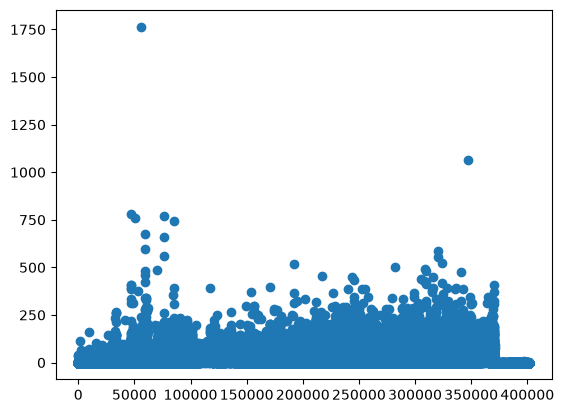

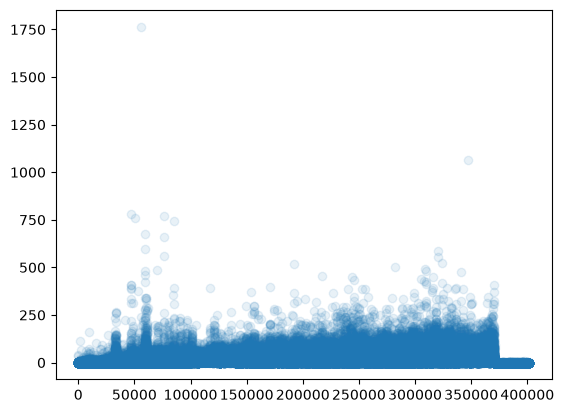

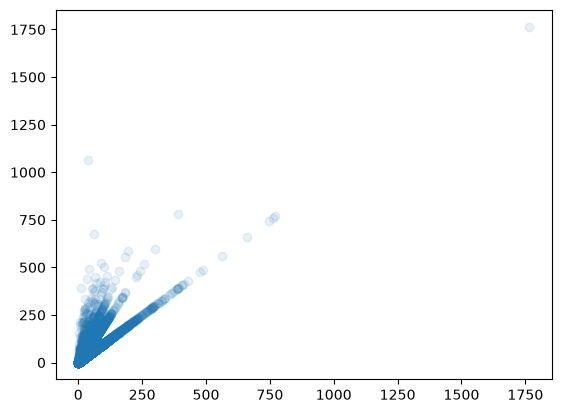

In [ ]:
#데이터 읽기: ns_book7.csv
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
#산점도 그리기: ‘번호’열에 대한 ‘대출건수’의 산점도
import matplotlib.pyplot as plt
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
plt.show()
#투명도 조절하기: alpha에 0~1값 지정
plt.scatter(ns_book7['번호'], ns_book7['대출건수'], alpha=0.1)
plt.show()

#도서권수와 대출건수 간의 관계
plt.scatter(ns_book7['대출건수']/ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

0.01933205582232549 0.9787262077473543


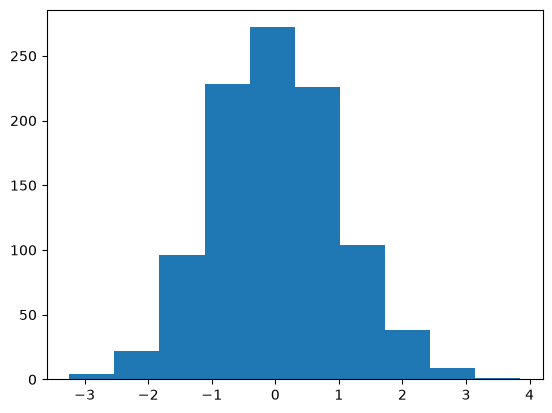

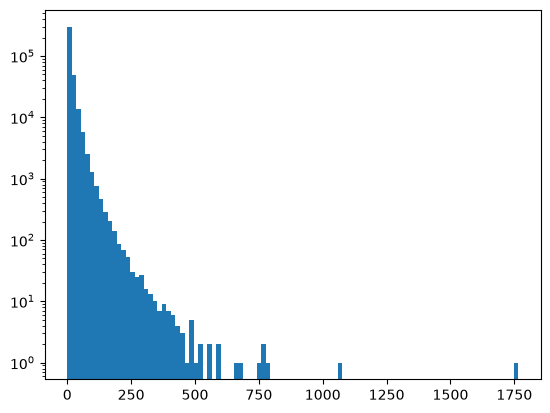

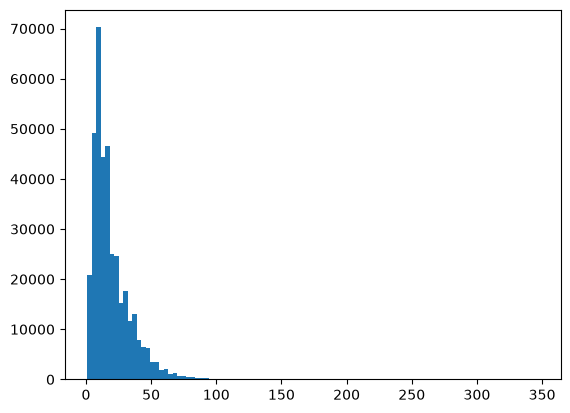

In [ ]:
#히스토그램 그리기
np.random.seed(42)
random_samples = np.random.randn(1000)
print(np.mean(random_samples), np.std(random_samples))
plt.hist(random_samples, bins=10)
plt.show()

#대출건수를 히스토그램으로 그리기
plt.hist(ns_book7['대출건수'], log=True, bins=100, range=(0, np.max(ns_book7['대출건수'])))
#log 매개변수를 사용하지 않고 plt.yscale('log')로 설정해도 됨
plt.show()
#도서명의 길이에 대한 히스토그램
title_len = ns_book7['도서명'].apply(len)
plt.hist(title_len, bins=100)
plt.show()

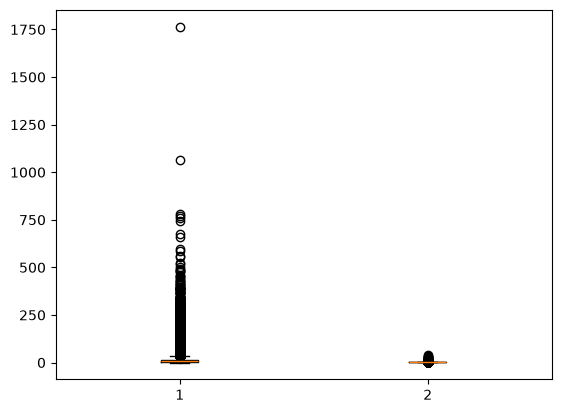

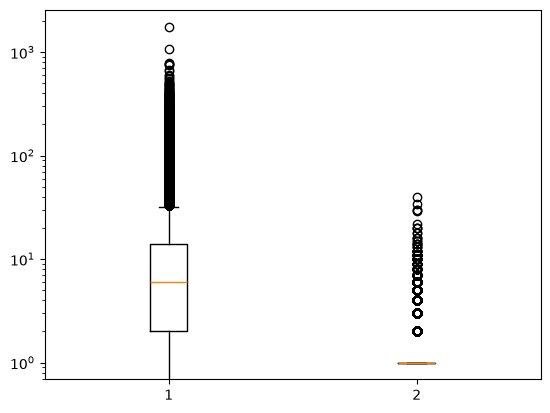

C:\Users\yccho\AppData\Local\Temp\ipykernel_21364\732098986.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)


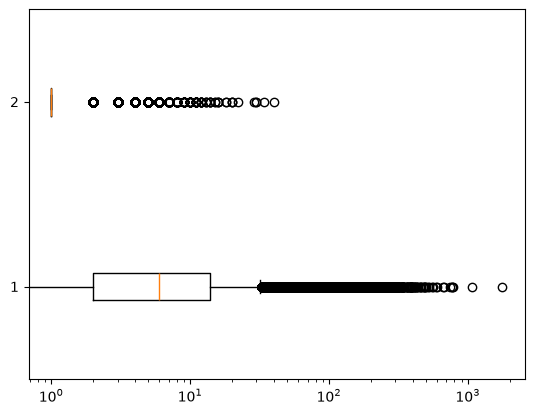

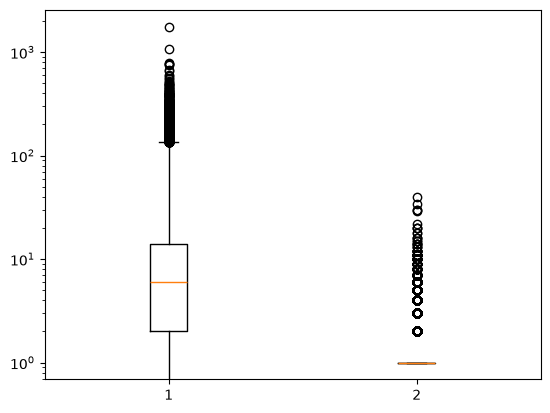

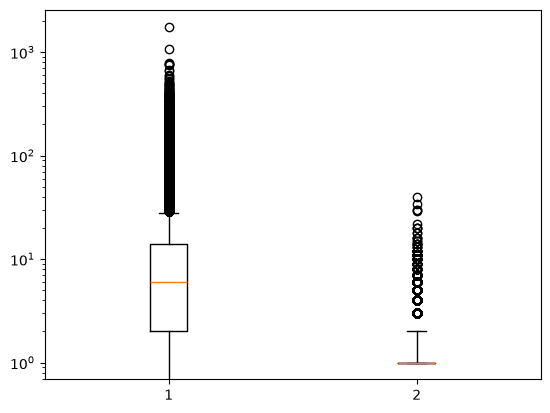

In [ ]:
#상자 수염 그림 그리기(box and whisker plot): 대출건수와 도서권수
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.show() #4분위수가 작아 상자가 보이지 않음

#Y축을 로그 스케일로 변경
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')
plt.show()

#수평 방향으로 그리기
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log')
plt.show()

#수염길이 조정: whis = 10(IQR의 10배), whis=(10,90)는 10%, 90% 백분위수에 해당하는 값까지
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)
plt.yscale('log')
plt.show()
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=(10,90))
plt.yscale('log')
plt.show()

* 판다스의 그래프 함수

<Axes: xlabel='도서권수', ylabel='대출건수'>

c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs

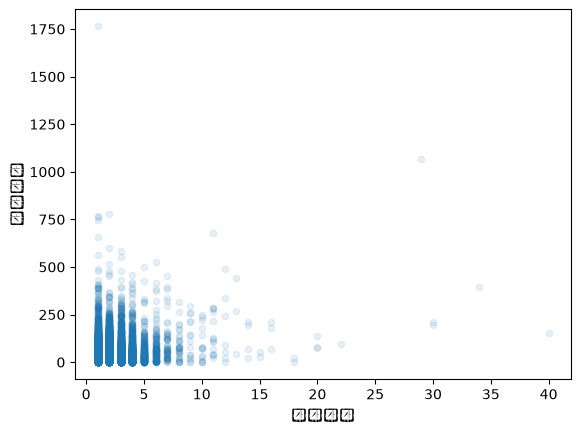

In [ ]:
#판다스에서 산점도 그리기
ns_book7.plot.scatter('도서권수', '대출건수', alpha=0.1) #도서권수는 X축 데이터, 대출건수는 Y축 데이터

<Axes: ylabel='Frequency'>

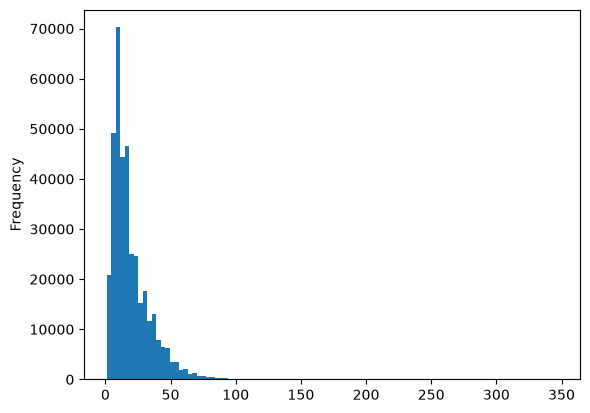

In [ ]:
#판다스에서 히스토그램 그리기: 도서명의 길이
ns_book7['도서명'].apply(len).plot.hist(bins=100)

<Axes: >

c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\room311\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\yccho\miniconda3\envs\

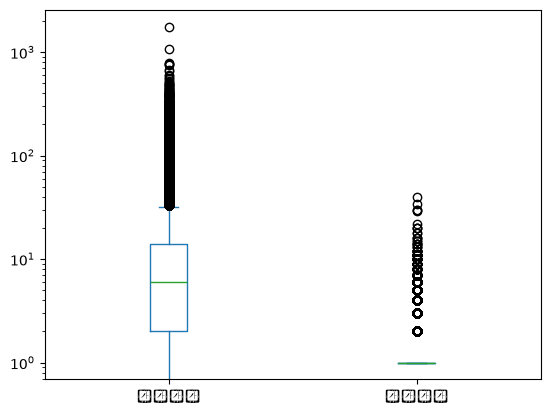

In [ ]:
#판다스에서 상자 수염 그림 그리기: 대출건수와 도서권수
ns_book7[['대출건수', '도서권수']].plot.box(logy=True)


# 5장 데이터 시각화하기
##### (1) 맷플롭립 기본 요소 알아보기

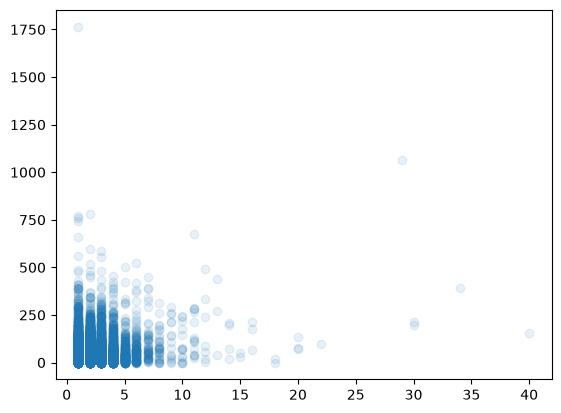

In [ ]:
#데이터 읽기: ns_book7.csv
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
#산점도 그리기: ‘번호’열에 대한 ‘대출건수’의 산점도
import matplotlib.pyplot as plt
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

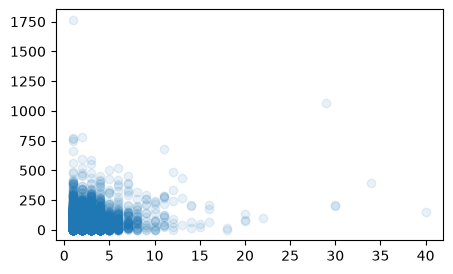

In [ ]:
#그래프의 크기 변경: figsize 매개변수 -> scatter()를 실행하기 전에 figure를 생성함
plt.figure(figsize=(5,3)) #단위는 인치
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

In [ ]:
#figure 크기 및 DPI값 확인
print(plt.rcParams['figure.figsize'])
print(plt.rcParams['figure.dpi'])

#DPI값 변경하기
plt.rcParams['figure.dpi'] = 100

#scatter() 그래프의 마커 변경하기
plt.rcParams['scatter.marker'] = '*'

[6.4, 4.8]
100.0


C:\Users\yccho\AppData\Local\Temp\ipykernel_21864\3514467500.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


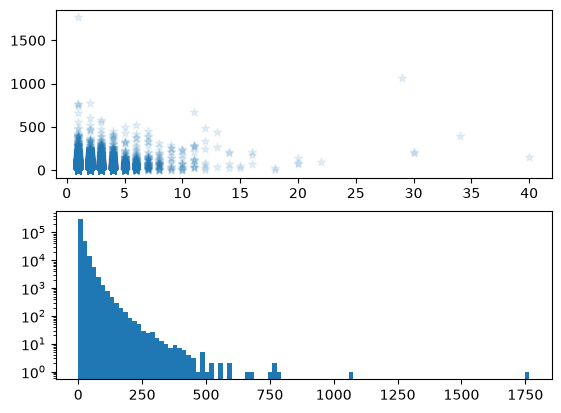

In [ ]:
#서브플롯 지정->산점도와 히스토그램 그리기
fig, axs = plt.subplots(2) #세로로 2개의 그림이 배치됨
axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
axs[1].hist(ns_book7['대출건수'], bins=100)
axs[1].set_yscale('log')
fig.show()

##### (2) 선 그래프와 막대 그래프 그리기

In [ ]:
#발행년도 열의 연도별 도서 권수를 추출함
count_by_year = ns_book7['발행년도'].value_counts()
count_by_year
#반환값을 연도순으로 재정렬
count_by_year = count_by_year.sort_index()
#2030년 이전 데이터만 추출
count_by_year = count_by_year[count_by_year.index < 2030]
type(count_by_year)

pandas.Series

In [ ]:
#주제별 도서 개수 구하기: 주제분류번호(예, 38.1) 이용
#주제분류번호를 입력 받아 첫 문자를 반환하고 NaN인 경우는 -1을 반환하는 함수
import numpy as np
def kdc_1st_char(no): #no는 주제분류번호
    if no is np.nan:
        return -1
    else:
        return no[0]
count_by_subject = ns_book7['주제분류번호'].apply(kdc_1st_char).value_counts()
type(count_by_subject)

pandas.Series

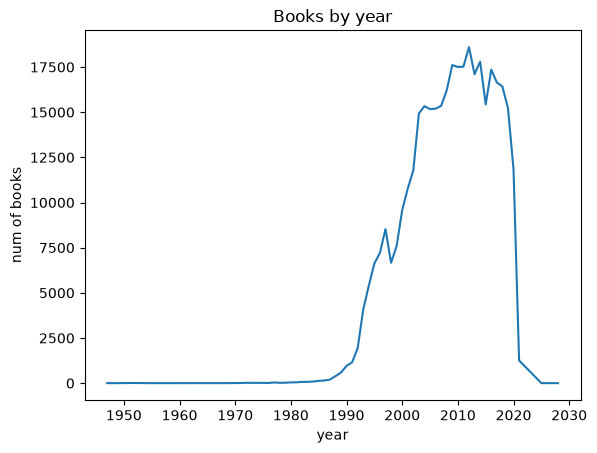

In [ ]:
#선 그래프 그리기: plot()
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100 #DPI를 100으로 설정(1인치 그림은 100픽셀로 그림)
#연도별 도서수 그리기
plt.plot(count_by_year.index, count_by_year.values)
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('num of books')
plt.show()

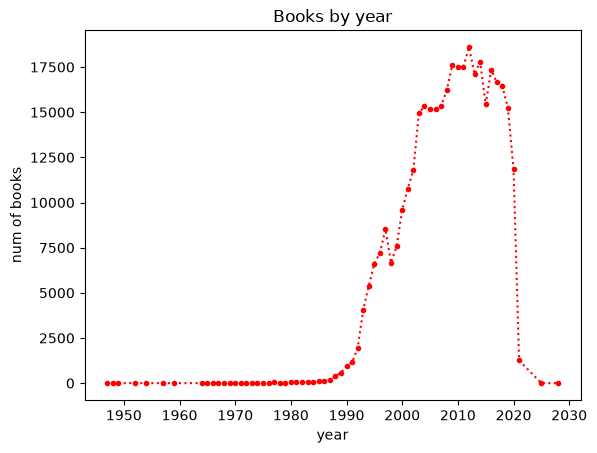

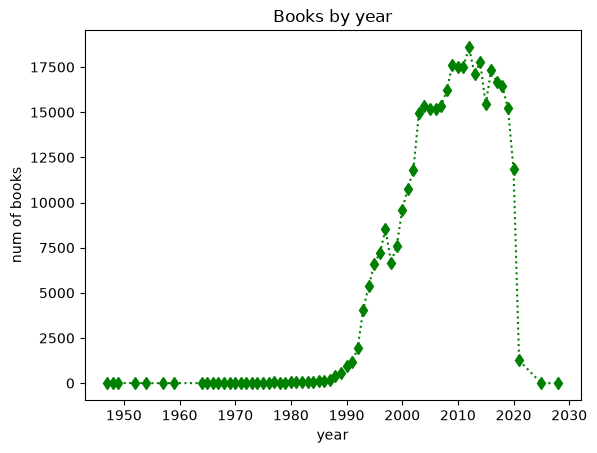

In [ ]:
#선의 종류와 마커 지정
plt.plot(count_by_year, marker='.', linestyle=':', color='red')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('num of books')
plt.show()
#다이어몬드 마커, 점선, 선색
plt.plot(count_by_year, ':dg')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('num of books')
plt.show()

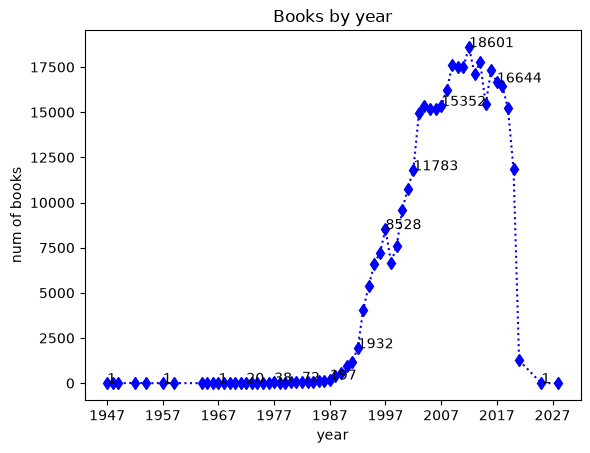

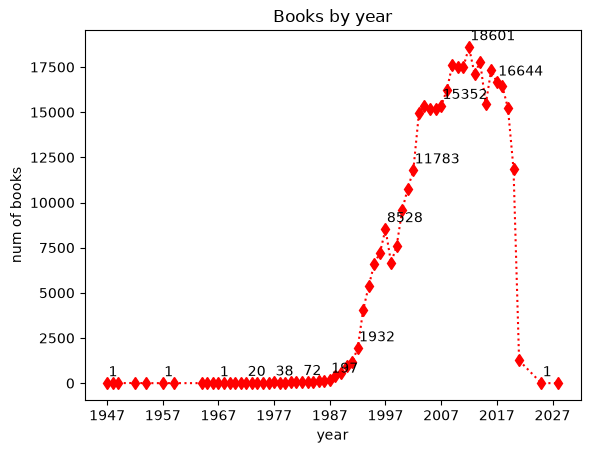

In [ ]:
#5행씩 건너뛴 연도별 도서수를 출력, 마커에 값을 함께 표시함
plt.plot(count_by_year, ':db')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('num of books')
plt.xticks(range(1947, 2030, 10)) #10년 간격으로 표시
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val)) #(idx, val)은 출력 위치(좌표)임
plt.show()

#마커에 텍스트를 x축으로 1만큼, y축으로 10만큼 띄워 출력하도록 지정함
plt.plot(count_by_year, ':dr')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('num of books')
plt.xticks(range(1947, 2030, 10)) #10년 간격으로 표시
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(1, 5), textcoords='offset points') #(idx, val)은 출력 위치(좌표)임
plt.show()

In [ ]:
type(count_by_subject.index)
type(count_by_subject.values)
count_by_subject.head()

주제분류번호
8    108643
3     80767
5     40916
9     26375
6     25070
Name: count, dtype: int64

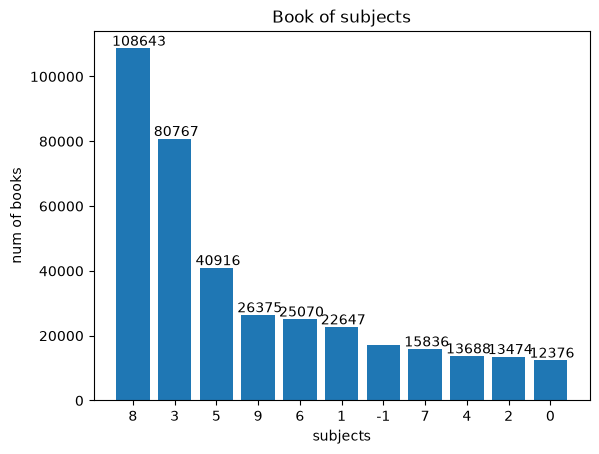

In [ ]:
#주제별 도서 수를 막대 그래프로 그리기
plt.bar(count_by_subject.index.astype(str), count_by_subject.values)
plt.title('Book of subjects')
plt.xlabel('subjects')
plt.ylabel('num of books')
for idx, value in count_by_subject.items():
    plt.annotate(value, (idx, value), xytext=(-15,2), textcoords='offset points')
plt.show()


In [ ]:
#matplotlib 폰트 캐시 삭제 후 재실행
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# 1. matplotlib 캐시 디렉터리 경로 확인 및 삭제
cache_dir = mpl.get_cachedir()
font_cache_file = os.path.join(cache_dir, 'fontlist-v330.json') # 버전에 따라 파일명이 조금 다를 수 있음

# 캐시 디렉터리 내 모든 파일 삭제
for file in os.listdir(cache_dir):
    if file.startswith('font') or file.endswith('.json'):
        try:
            os.remove(os.path.join(cache_dir, file))
            print(f"삭제 완료: {file}")
        except Exception as e:
            pass

print("폰트 캐시 삭제가 완료되었습니다.")

폰트 캐시 삭제가 완료되었습니다.


In [ ]:
from matplotlib.font_manager import findSystemFonts
findSystemFonts()

['C:\\Windows\\Fonts\\SansSerifCollection.ttf',
 'C:\\Windows\\Fonts\\MalangmalangB.ttf',
 'C:\\Windows\\Fonts\\verdanaz.ttf',
 'C:\\Windows\\Fonts\\AGENCYR.TTF',
 'C:\\Windows\\Fonts\\SHOWG.TTF',
 'C:\\Windows\\Fonts\\LHANDW.TTF',
 'C:\\Windows\\Fonts\\LATINWD.TTF',
 'C:\\Windows\\Fonts\\segoepr.ttf',
 'C:\\Windows\\Fonts\\courbd.ttf',
 'C:\\Users\\yccho\\AppData\\Local\\Microsoft\\Windows\\Fonts\\KoPubDotumLight.ttf',
 'C:\\Windows\\Fonts\\framd.ttf',
 'C:\\Windows\\Fonts\\PERTILI.TTF',
 'C:\\Windows\\Fonts\\BASKVILL.TTF',
 'C:\\Windows\\Fonts\\consola.ttf',
 'C:\\Windows\\Fonts\\taileb.ttf',
 'C:\\Windows\\Fonts\\BSSYM7.TTF',
 'C:\\Windows\\Fonts\\POORICH.TTF',
 'C:\\Users\\yccho\\AppData\\Local\\Microsoft\\Windows\\Fonts\\NanumGothicLight.ttf',
 'C:\\Windows\\Fonts\\mmrtext.ttf',
 'C:\\Windows\\Fonts\\tahoma.ttf',
 'C:\\Windows\\Fonts\\seguihis.ttf',
 'C:\\Windows\\Fonts\\HANBatangExtB.ttf',
 'C:\\Windows\\Fonts\\HanSantteutDotum-Regular.ttf',
 'C:\\Windows\\Fonts\\TEMPSITC.TTF',
 

In [ ]:
plt.rcParams['font.family']='NanumBarunGothic'
plt.rc('font',family='NanumBarunGothic')
print(plt.rcParams['font.family'], plt.rcParams['font.size'])
#count_by_subject.plot.bar()

['NanumBarunGothic'] 10.0


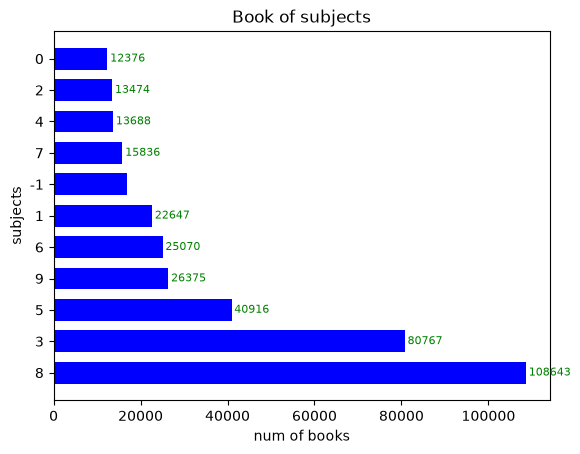

In [ ]:
#가로 막대 그래프 그리기
plt.barh(count_by_subject.index.astype(str), count_by_subject.values, height=0.7, color='blue')
plt.title('Book of subjects')
plt.ylabel('subjects')
plt.xlabel('num of books')
for idx, value in count_by_subject.items():
    plt.annotate(value, (value, idx), xytext=(2,0), textcoords='offset points', fontsize=8, va='center', color='green')
plt.show()

#### [좀 더 알아보기] 이미지 출력, 저장

In [ ]:
#예제 이미지 다운로드: jupiter.png
import gdown
gdown.download('https://bit.ly/3wrj4xf', 'jupiter.png', quiet=False)

Downloading...
From: https://bit.ly/3wrj4xf
To: e:\working\pythonBasic\HonGong-DataAnalysis_py\jupiter.png
100%|██████████| 3.29M/3.29M [00:00<00:00, 46.9MB/s]


'jupiter.png'

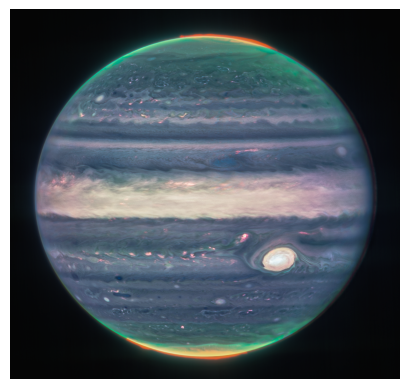

In [ ]:
#예제 이미지 읽기
import matplotlib.pyplot as plt
img = plt.imread('jupiter.png')
img.shape
#이미지 출력
plt.imshow(img)
plt.axis('off') #축 표시 해제
plt.show()

In [ ]:
#이미지 저장하기: imsave() 함수, 이미지를 넘파이 배열로 바꾸어야 함
import numpy as np
arr_img = np.array(img) #img도 넘파이 배열임
plt.imsave('jupiter.jpg', img)

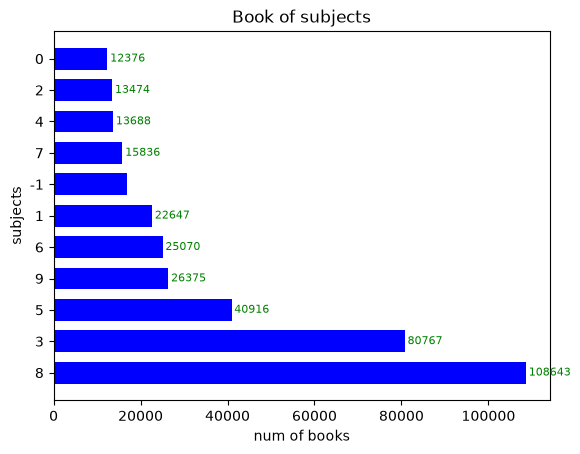

In [ ]:
#plt 그래프를 파일로 저장하기: savefig() 함수
plt.barh(count_by_subject.index.astype(str), count_by_subject.values, height=0.7, color='blue')
plt.title('Book of subjects')
plt.ylabel('subjects')
plt.xlabel('num of books')
for idx, value in count_by_subject.items():
    plt.annotate(value, (value, idx), xytext=(2,0), textcoords='offset points', fontsize=8, va='center', color='green')
plt.savefig('books_by_subject.png')
plt.show()

# 6장 복잡한 데이터 표현하기
##### (1) 객체지향 API로 그래프 꾸미기

In [4]:
#출판사별 발행 도서 개수 산점도 그리기
#데이터 읽기: ns_book7.csv
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)

#출판사 개수 출력
top30_pubs = ns_book7['출판사'].value_counts()[:30]
top30_pubs
print(top30_pubs.values.sum())
top30_pubs.index[:30]

#출판사 열에서 상위 30위의 출판사가 있는 행에 대한 불리어 배열을 저장함
top30_pubs_idx = ns_book7['출판사'].isin(top30_pubs.index)
top30_pubs_idx.sum() #True는 1로, False는 0으로 합산함-> 위의 top30_pubs.values.sum()와 같음

#상위 30위 출판사인지가 인덱스로 표시된 데이터프레임에서 무작위로 1000개의 행(샘플)을 선택하여 ns_book8로 저장
ns_book8 = ns_book7[top30_pubs_idx].sample(1000, random_state=42) #sample()은 top30_pubs_idx가 True인 것에서만 선택함
#ns_book8.head()

51886


C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\2986326155.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


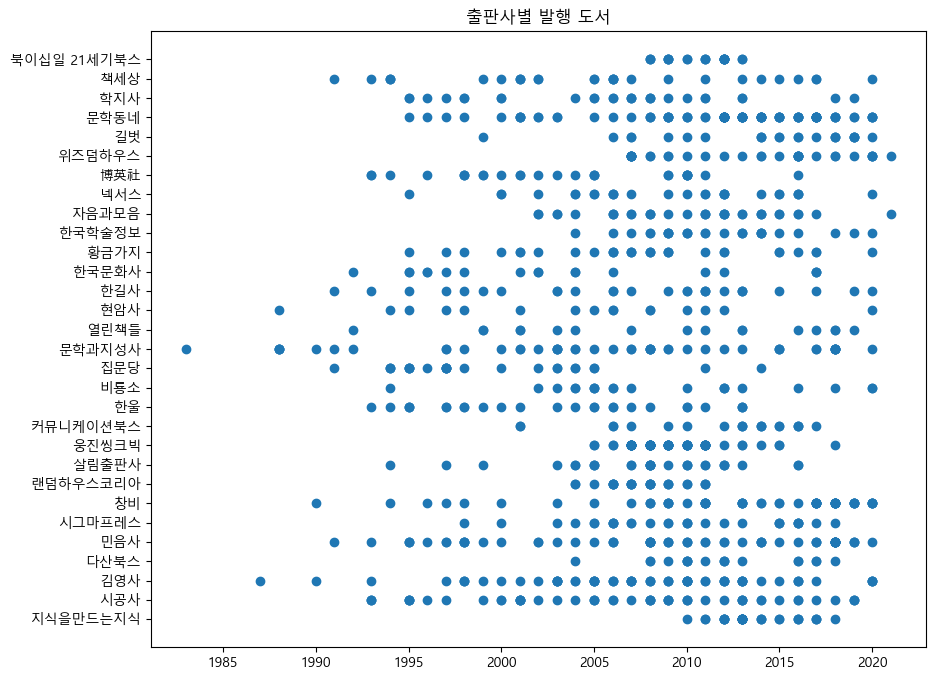

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
#plt.rc('font', family='Malgun Gothic')
#plt.rc('axes', unicode_minus=False)

#ns_book8에 대해 산점도 그리기(객체지향 API 사용)
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], marker='o')
ax.set_title('출판사별 발행 도서')
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\480626434.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


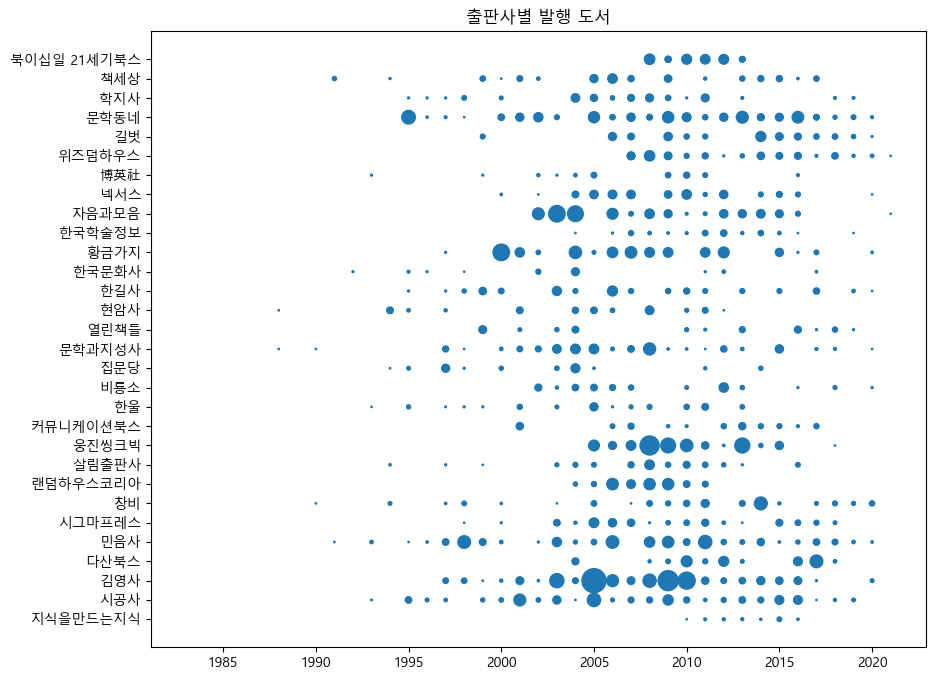

In [7]:
#마커 크기를 대출건수에 비례하여 가변적으로 표시되기
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], marker='o', s=ns_book8['대출건수'])
ax.set_title('출판사별 발행 도서')
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\3860580140.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


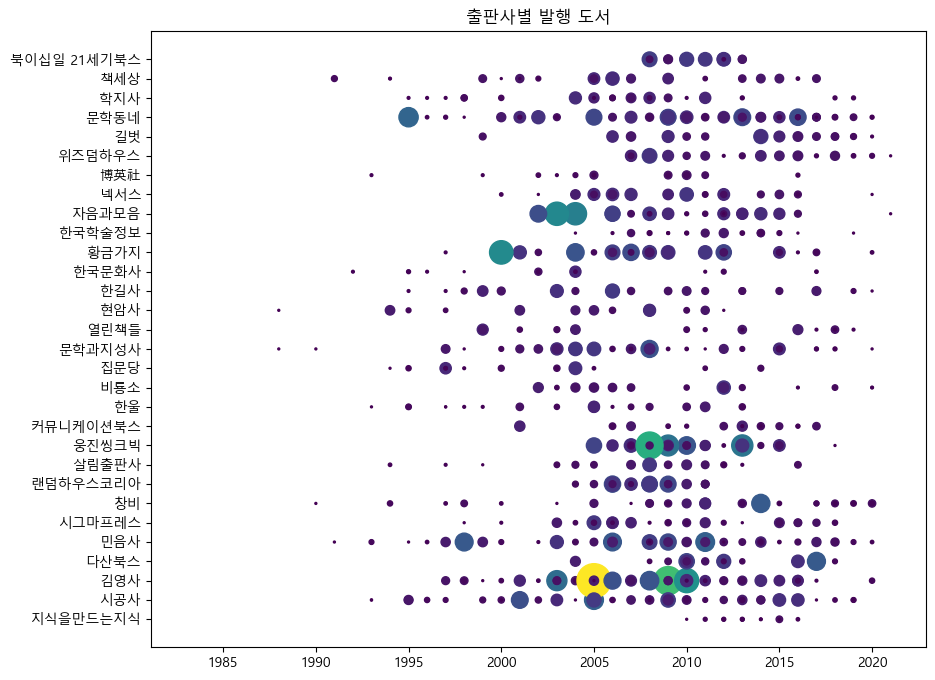

In [8]:
#마커 색을 대출건수 값에 따라 다르게 출력하기
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], marker='o', s=ns_book8['대출건수']*2, c=ns_book8['대출건수'])
ax.set_title('출판사별 발행 도서')
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\1435467816.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


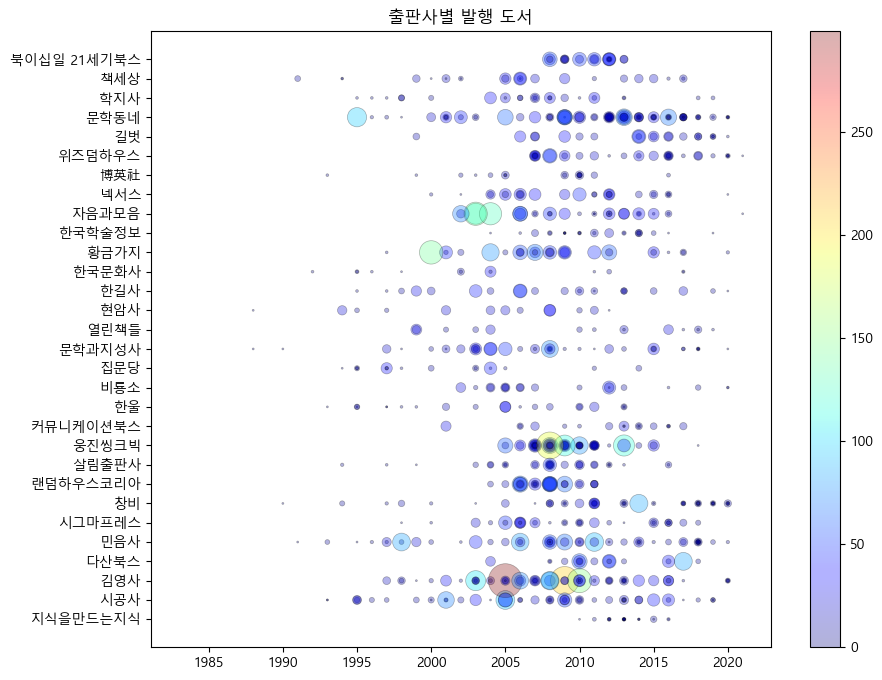

In [9]:
#컬러맵 사용하여 출력하기
fig, ax = plt.subplots(figsize=(10,8))
sc = ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], marker='o', s=ns_book8['대출건수']*2, c=ns_book8['대출건수'], linewidths=0.5, edgecolors='k', alpha=0.3, cmap='jet')
ax.set_title('출판사별 발행 도서')
fig.colorbar(sc)
fig.show()

##### (2) 맷플롭립의 고급 기능 배우기
* 선 그래프를 여러 개 그리기

In [10]:
#데이터 읽기: ns_book7.csv
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)

#상위 30위 출판사에 대한 행에서 출판사, 발행년도, 대출건수 열만 추출하여 ns_book9 데이터프레임으로 저장
top30_pubs = ns_book7['출판사'].value_counts() #출판사별로 수를 내림차순으로 반환함
top30_pubs_idx = ns_book7['출판사'].isin(top30_pubs.index) #인덱스가 출판사명임
ns_book9 = ns_book7[top30_pubs_idx][['출판사','발행년도','대출건수']]
ns_book9.head()

#ns_book9에서 출판사와 발행년도를 인덱스로 이에 대해 대출건수를 합침
ns_book9 = ns_book9.groupby(by=['출판사', '발행년도']).sum()

#인덱스를 해제함
ns_book9 = ns_book9.reset_index()
ns_book9[ns_book9['출판사']=='황금가지'].head()

,출판사,발행년도,대출건수
77053,황금가지,1995,0.0
77054,황금가지,1996,67.0
77055,황금가지,1997,116.0
77056,황금가지,1998,526.0
77057,황금가지,1999,505.0


C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\135475486.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


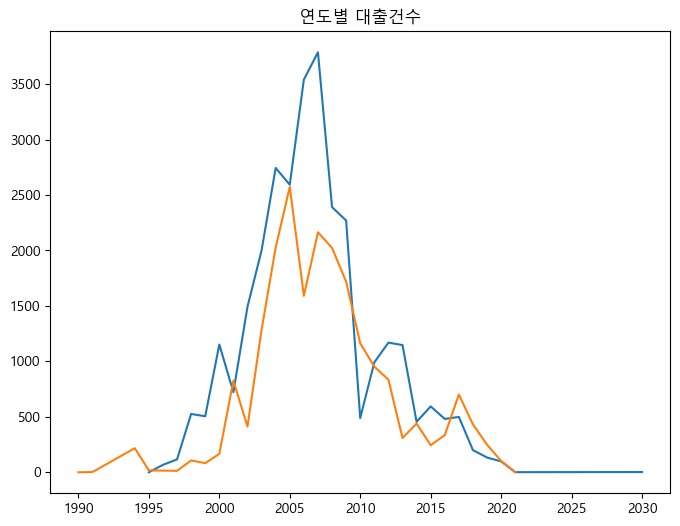

In [13]:
#출판사가 황금가지인 행과 비룡소인 행만 추출하여 발행년도별 대출건수 그래프를 그림
line1 = ns_book9[ns_book9['출판사']=='황금가지']
line2 = ns_book9[ns_book9['출판사']=='비룡소']
#line1(황금가지), line2(비룡사)에 대한 발행년도별 대출건수 그래프를 그림
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(line1['발행년도'], line1['대출건수'])
ax.plot(line2['발행년도'], line2['대출건수'])
ax.set_title('연도별 대출건수')
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\3897881820.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


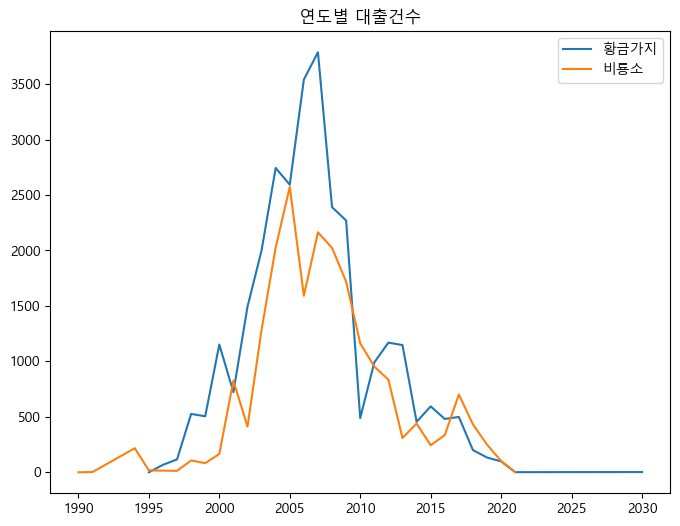

In [14]:
#그래프에 범례 추가
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(line1['발행년도'], line1['대출건수'], label="황금가지")
ax.plot(line2['발행년도'], line2['대출건수'], label="비룡소")
ax.set_title('연도별 대출건수')
ax.legend()
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\2997381581.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


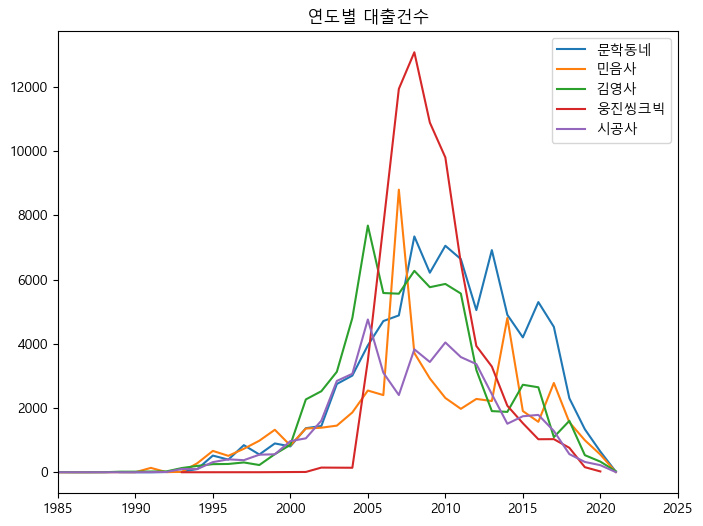

In [15]:
#5개 그래프 그리기
fig, ax = plt.subplots(figsize=(8,6))
for pub in top30_pubs.index[:5]: #top30_pubs는 30위 이내 출판사의 인덱스 5개를 가져옴
    line = ns_book9[ns_book9['출판사']==pub]
    ax.plot(line['발행년도'], line['대출건수'], label=pub) #pub:출판사명
ax.legend()
ax.set_title('연도별 대출건수')
ax.set_xlim(1985, 2025)
fig.show()

In [20]:
ns_book9.head()

,출판사,발행년도,대출건수
0,겨레,1995,22.0
1,겨레,1998,0.0
2,Yoonseok Multimedia한국심리검사,2001,0.0
3,교원,1999,1.0
4,매경출판,2015,44.0


* 스택영역 그래프 그리기

Index(['문학동네', '민음사', '김영사', '웅진씽크빅', '시공사', '창비', '문학과지성사', '위즈덤하우스', '학지사',
       '한울'],
      dtype='str', name='출판사')
       대출건수                                               ...                 \
발행년도   1947 1948 1949 1952 1954 1957 1959 1964 1965 1966  ... 2542 2544 2545   
출판사                                                       ...                  
문학동네    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
민음사     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
김영사     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
웅진씽크빅   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
시공사     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
창비      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
문학과지성사  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
위즈덤하우스  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0 

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\1172649879.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


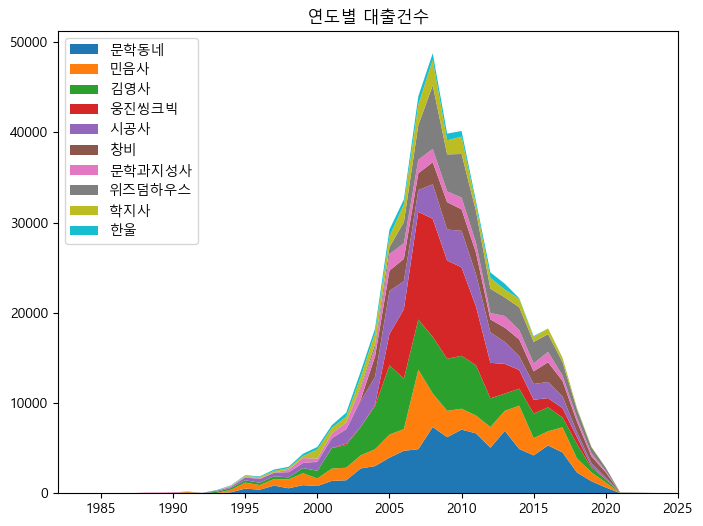

In [38]:
#스택영역 그래프
fig, ax=plt.subplots(figsize=(8,6))
ns_book10 = ns_book9.pivot_table(index=ns_book9['출판사'], columns=ns_book9['발행년도']) #ns_book10은 2차원 배열임
top10_pubs = top30_pubs.index[:10] #상위 30개 출판사 인덱스에서 상위 10개 인덱스만 따로 저장
print(top10_pubs) #10개의 인덱스(출판사명)
print(ns_book10.loc[top10_pubs].fillna(0))
year_cols = ns_book10.columns.get_level_values(1)
ax.stackplot(year_cols, ns_book10.loc[top10_pubs].fillna(0), labels=top10_pubs) #fillna(0)은 누락된 값을 0으로 채움
ax.set_title('연도별 대출건수')
ax.legend(loc='upper left') #'best'일 때는 최상의 위치로 선정
ax.set_xlim(1982, 2025)
fig.show()

* 막대 그래프를 여러 개 그리기

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\704832801.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


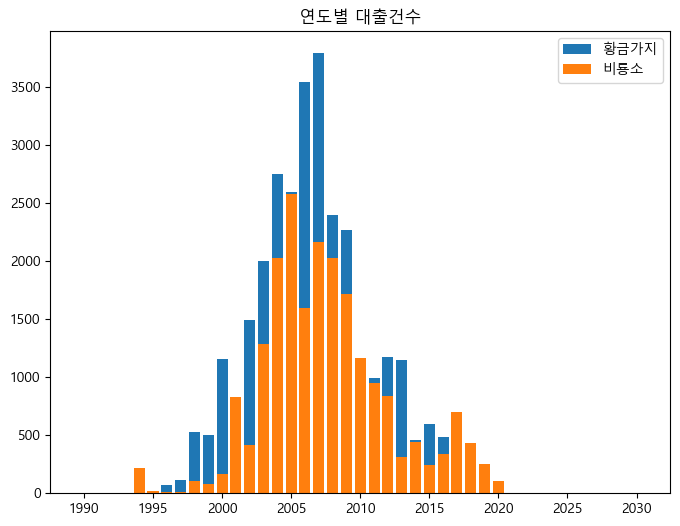

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(line1['발행년도'], line1['대출건수'], label='황금가지')
ax.bar(line2['발행년도'], line2['대출건수'], label='비룡소')
ax.set_title('연도별 대출건수')
ax.legend()
fig.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\2957548658.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


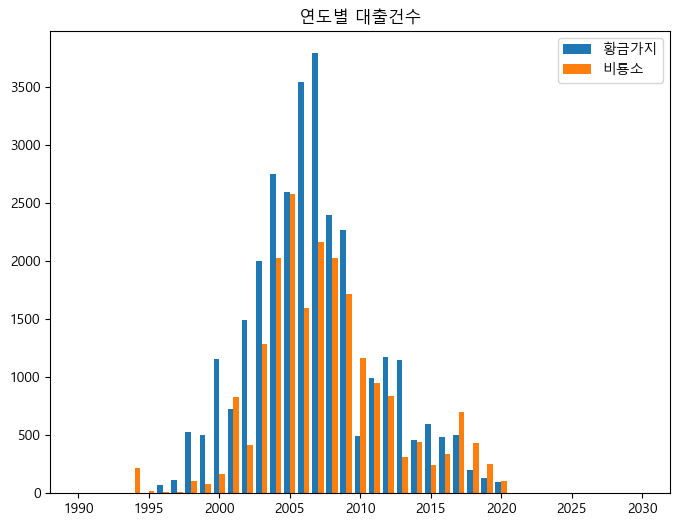

In [41]:
#막대 그래프 2개를 비껴서 그림
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(line1['발행년도']-0.2, line1['대출건수'], width=0.4, label='황금가지')
ax.bar(line2['발행년도']+0.2, line2['대출건수'], width=0.4, label='비룡소')
ax.set_title('연도별 대출건수')
ax.legend()
fig.show()

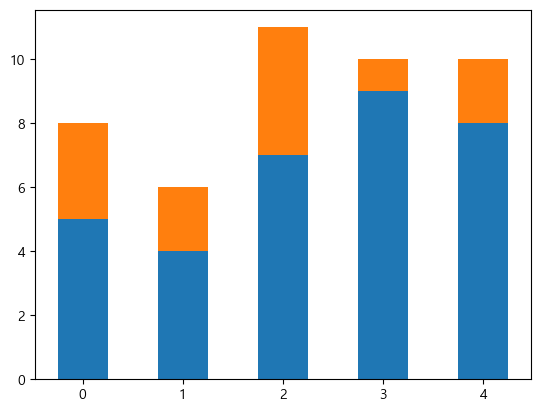

In [42]:
#스택 막대 그래프 기본 개념
height1 = [5,4,7,9,8]
height2 = [3,2,4,1,2]
plt.bar(range(5), height1, width=0.5)
plt.bar(range(5), height2, bottom=height1, width=0.5)
plt.show()

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\650167399.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


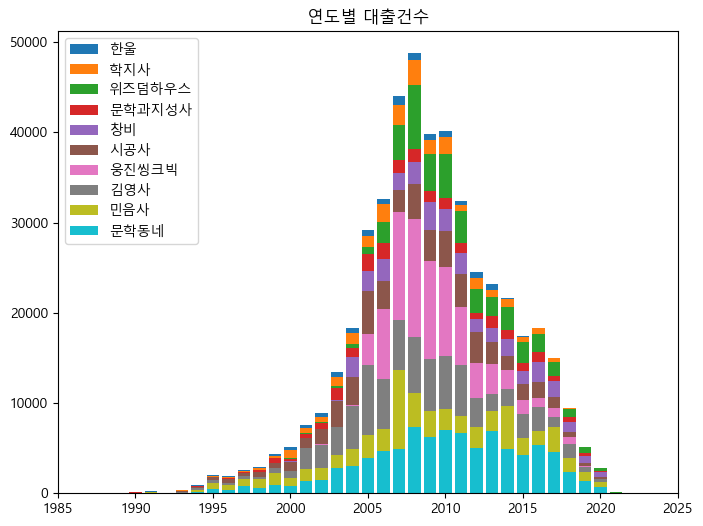

In [43]:
#데이터를 열 기준으로 cumsum()함수로 누적한 후, 큰 값을 갖는 마지막 행부터 거꾸로 그리기: 겹쳐 그리기 때문에 쌓아 그린 것처럼 나타남
ns_book12 = ns_book10.loc[top10_pubs].cumsum() #loc[]로 10개의 행을 추출한 후, cumsum()은 axis=0이 기본 설정이므로 열을 따라 누적함
year_cols = ns_book10.columns.get_level_values(1)
fig, ax = plt.subplots(figsize=(8,6))
for i in reversed(range(len(ns_book12))):
    bar = ns_book12.iloc[i] #행 추출
    label = ns_book12.index[i]
    ax.bar(year_cols, bar, label=label)
ax.set_title('연도별 대출건수')
ax.legend(loc='upper left')
ax.set_xlim(1985, 2025)
fig.show()

* 원 그래프 그리기

C:\Users\yccho\AppData\Local\Temp\ipykernel_40604\2827378625.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


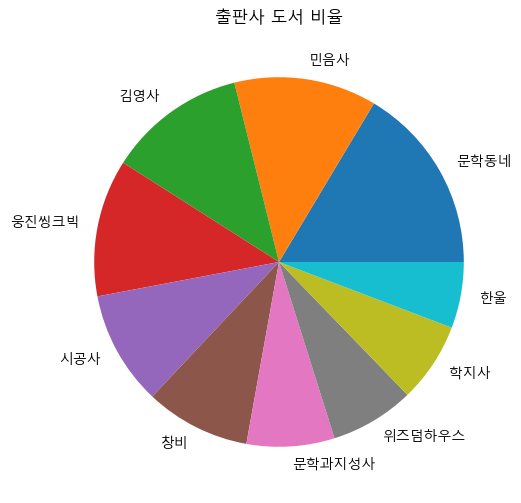

In [46]:
#top30_pubs 인 상위 30개 출판사에서 10개를 추출함
data = top30_pubs[:10] #이는 출판사명과 출판사별 대출건수를 갖는 데이터프레임임
labels = top30_pubs.index[:10] #인덱스(상위 10개 출판사명)만 가져옴

fig, ax=plt.subplots(figsize=(8,6))
ax.pie(data, labels=labels)
ax.set_title('출판사 도서 비율')
fig.show()

# 7장 검증하고 예측하기
##### (1) 통계적으로 추론하기
##### (2) 머신러닝으로 예측하기